# Chapter 10. Mechanistic Interpretability: Circuits, Features, and Sparse Autoencoders

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mohammadi-hadi/hands-on-xai-labs/blob/main/notebooks/ch10-mechanistic-interpretability.ipynb)

Companion notebook for Chapter 10 of *Hands-On Explainable AI*.

**What you'll build:** four escalating probes into GPT-2 small. First a behavioral scan that finds its induction heads (the tiny circuit behind in-context copying). Then an activation-patching experiment that localizes where "the Eiffel Tower is in *Paris*" lives inside the network, and does so causally rather than by staring at attention maps. Then a sparse autoencoder that unmixes the layer-8 residual stream into 24,576 candidate features, with a mini feature dashboard built from 200 real tweets. Finally, a steering hook that adds one feature's decoder vector back into the residual stream and pushes the model toward San Francisco, including what happens when you push too hard.

This lab is part of *Hands-On Explainable AI: Interpreting, Evaluating, and Trusting Large Language Models* by [Hadi Mohammadi](https://mohammadi.cv). Code is MIT licensed; the repository and citation info live at [hands-on-xai-labs](https://github.com/mohammadi-hadi/hands-on-xai-labs) (DOI: [10.5281/zenodo.21804605](https://doi.org/10.5281/zenodo.21804605)).

In [1]:
%%capture
import importlib.util
IN_COLAB = importlib.util.find_spec("google.colab") is not None
if IN_COLAB:
    %pip install -q transformer-lens==2.9.0 sae-lens==6.5.3 datasets==3.6.0

In [2]:
import functools
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Smoke mode: CI sets BOOK_SMOKE=1, sections 4-5 (SAE download) are skipped
SMOKE = os.environ.get("BOOK_SMOKE") == "1"
DEVICE = os.environ.get("BOOK_DEVICE") or (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
# silence library chatter that would clutter saved outputs (results are unaffected)
import warnings

warnings.filterwarnings("ignore", module="sae_lens.*")  # see note in section 4
from transformers.utils import logging as hf_logging

hf_logging.set_verbosity_error()

_style = Path("../styles/book.mplstyle")
if _style.exists():
    plt.style.use(_style)
INK, RUST, TEAL, AMBER, ROSE, STONE = "#1A1C1E", "#9A3412", "#0D9488", "#F59E0B", "#E11D48", "#A8A29E"
print(f"device={DEVICE} smoke={SMOKE}")

device=mps smoke=False


## 1. A model with handles

In Chapter 3 we pried GPT-2 open with raw `transformers`: output flags, manual hooks, a hand-built logit lens. `transformer-lens` packages that workflow: it loads the same weights but names **every intermediate tensor** as a hook point you can read *or overwrite*. That second part is the whole game in this chapter: mechanistic claims are causal claims, and causal claims need intervention points.

In [3]:
from transformer_lens import HookedTransformer

model = HookedTransformer.from_pretrained("gpt2", device=DEVICE)
model.eval()
torch.set_grad_enabled(False)  # interventions only, no training
print(f"gpt2-small: {model.cfg.n_layers} layers x {model.cfg.n_heads} heads, d_model={model.cfg.d_model}")

toks = model.to_tokens("Explainability is a systems property.")
_, cache = model.run_with_cache(toks)
block5 = [name for name in cache.keys() if name.startswith("blocks.5.")]
print(f"\n{len(cache)} named activations cached; the {len(block5)} inside block 5 alone:")
for name in block5:
    print(f"  {name:42s} {tuple(cache[name].shape)}")

Loaded pretrained model gpt2 into HookedTransformer
gpt2-small: 12 layers x 12 heads, d_model=768

208 named activations cached; the 17 inside block 5 alone:
  blocks.5.hook_resid_pre                    (1, 9, 768)
  blocks.5.ln1.hook_scale                    (1, 9, 1)
  blocks.5.ln1.hook_normalized               (1, 9, 768)
  blocks.5.attn.hook_q                       (1, 9, 12, 64)
  blocks.5.attn.hook_k                       (1, 9, 12, 64)
  blocks.5.attn.hook_v                       (1, 9, 12, 64)
  blocks.5.attn.hook_attn_scores             (1, 12, 9, 9)
  blocks.5.attn.hook_pattern                 (1, 12, 9, 9)
  blocks.5.attn.hook_z                       (1, 9, 12, 64)
  blocks.5.hook_attn_out                     (1, 9, 768)
  blocks.5.hook_resid_mid                    (1, 9, 768)
  blocks.5.ln2.hook_scale                    (1, 9, 1)
  blocks.5.ln2.hook_normalized               (1, 9, 768)
  blocks.5.mlp.hook_pre                      (1, 9, 3072)
  blocks.5.mlp.hook_post       

## 2. Finding induction heads by behavior

Induction heads are the classic first circuit: a head that, at token `B` in a sequence `... A B ... A`, looks back at the *previous* `B`. Wait, more precisely: at position `A` (second occurrence) it attends to the token that **followed** `A` last time, and copies it forward. They are the mechanism behind the simplest form of in-context learning.

The test is behavioral, and that's the point: we don't inspect weights, we hand the model a sequence of 50 random tokens **repeated twice** and measure, for each of the 144 heads, how much attention flows from each second-half token to the token one step after its first occurrence. Random tokens kill every other strategy: no grammar, no facts, nothing to do *except* copy the pattern.

In [4]:
n_layers, n_heads = model.cfg.n_layers, model.cfg.n_heads
SEQ_LEN = 25 if SMOKE else 50
BATCH = 2 if SMOKE else 4

rand_toks = torch.randint(1000, 20000, (BATCH, SEQ_LEN))
bos = torch.full((BATCH, 1), model.tokenizer.bos_token_id)
rep_toks = torch.cat([bos, rand_toks, rand_toks], dim=1).to(DEVICE)  # [batch, 1 + 2*SEQ_LEN]

_, ind_cache = model.run_with_cache(rep_toks, names_filter=lambda name: name.endswith("pattern"))

induction_scores = torch.zeros(n_layers, n_heads)
q_pos = torch.arange(SEQ_LEN + 1, 2 * SEQ_LEN)  # queries in the second copy
k_pos = q_pos - SEQ_LEN + 1                     # the token AFTER the previous occurrence
for layer in range(n_layers):
    pattern = ind_cache["pattern", layer]       # [batch, head, query, key]
    induction_scores[layer] = pattern[:, :, q_pos, k_pos].mean(dim=(0, 2)).cpu()

top_heads = induction_scores.flatten().topk(5)
print("top induction heads (mean attention to the induction target):")
for val, idx in zip(top_heads.values, top_heads.indices):
    print(f"  L{idx.item() // n_heads}H{idx.item() % n_heads}: {val:.3f}")

top induction heads (mean attention to the induction target):
  L5H5: 0.945
  L6H9: 0.921
  L7H10: 0.911
  L5H1: 0.902
  L7H2: 0.853


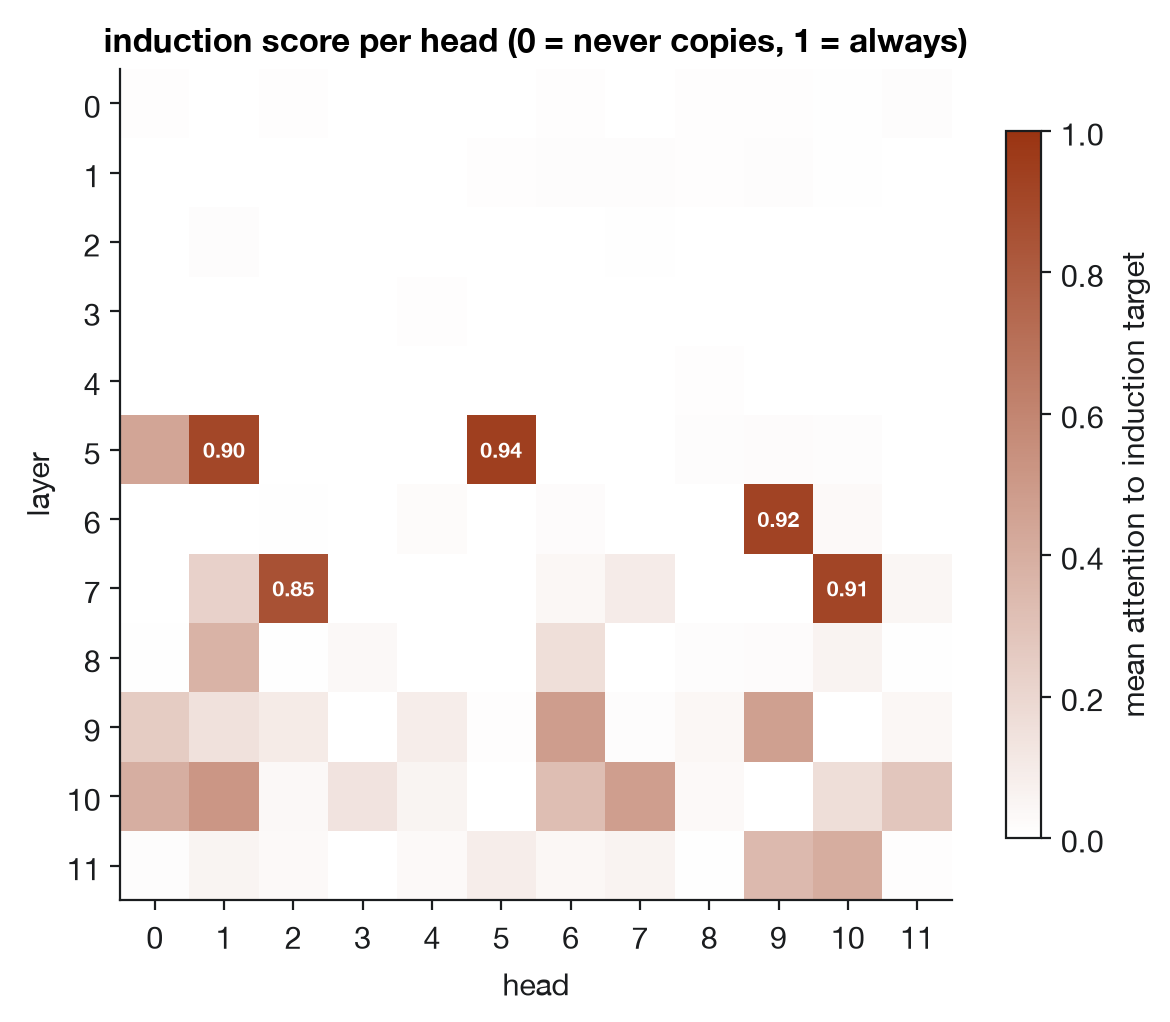

In [5]:
#| label: fig-induction-heads
#| fig-cap: "Induction score for all 144 GPT-2 small heads on twice-repeated random tokens: a handful of heads in layers 5-7 do almost all the copying, the rest sit near zero."
#| fig-alt: "Heatmap of induction scores for all 144 GPT-2 small heads: a handful of heads in layers 5 to 7 score high while the rest stay near zero."
from matplotlib.colors import LinearSegmentedColormap

rust_cmap = LinearSegmentedColormap.from_list("rust", ["#FFFFFF", RUST])

fig, ax = plt.subplots(figsize=(7, 5.4))
im = ax.imshow(induction_scores, cmap=rust_cmap, vmin=0, vmax=1)
for val, idx in zip(top_heads.values, top_heads.indices):
    layer, head = divmod(idx.item(), n_heads)
    ax.text(head, layer, f"{val:.2f}", ha="center", va="center",
            fontsize=7.5, color="white", fontweight="bold")
ax.set_xticks(range(n_heads))
ax.set_yticks(range(n_layers))
ax.set_xlabel("head")
ax.set_ylabel("layer")
ax.set_title("induction score per head (0 = never copies, 1 = always)")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.85, label="mean attention to induction target")
plt.show()

The hits are sharp, not diffuse: about five heads in layers 5-7 score above 0.85 while most of the other 139 sit below 0.1. These are the same heads the original induction-head papers flag for GPT-2 small. We recovered them with 20 lines and one forward pass. That sharpness is what makes "circuit" more than a metaphor, and it's the existence proof that motivates everything below: if *this* structure is findable, what else is?

## 3. From correlation to causation: activation patching

Chapters 3-5 *watched* the model (logit lens, attention maps), and Chapter 5 showed how watching misleads. Activation patching intervenes instead. The recipe:

1. Run a **clean** prompt ("The Eiffel Tower is in the city of", completing to Paris) and cache every activation.
2. Run a **corrupted** prompt that differs only in the subject ("The Colosseum is in the city of", completing to Rome).
3. Re-run the corrupted prompt, but at ONE chosen (layer, position) overwrite the residual stream with the clean run's value. If the model now says Paris again, the Paris-information was flowing through that exact point.

Our yardstick is the **logit difference** `logit(' Paris') − logit(' Rome')`: a directional measure that works even when neither city is the top prediction, and (unlike probabilities) is comparable across interventions.

In [6]:
clean_prompt = "The Eiffel Tower is in the city of"
corrupt_prompt = "The Colosseum is in the city of"
clean_toks = model.to_tokens(clean_prompt)
corrupt_toks = model.to_tokens(corrupt_prompt)
assert clean_toks.shape == corrupt_toks.shape, "patching needs position-aligned prompts"
print("positions:", model.to_str_tokens(clean_prompt))

PARIS = model.to_single_token(" Paris")
ROME = model.to_single_token(" Rome")

def logit_diff(logits):
    return logits[0, -1, PARIS] - logits[0, -1, ROME]

clean_logits, clean_cache = model.run_with_cache(clean_toks)
corrupt_logits = model(corrupt_toks)
CLEAN_DIFF = logit_diff(clean_logits).item()
CORRUPT_DIFF = logit_diff(corrupt_logits).item()
print(f"logit diff (Paris - Rome): clean {CLEAN_DIFF:+.3f} | corrupted {CORRUPT_DIFF:+.3f}")

for name, lg in [("clean", clean_logits), ("corrupted", corrupt_logits)]:
    probs = torch.softmax(lg[0, -1], dim=-1)
    tk = probs.topk(3)
    preds = ", ".join(f"{model.to_string(i.item())!r} {v:.3f}" for v, i in zip(tk.values, tk.indices))
    print(f"  {name:9s} top-3: {preds}")

positions: ['<|endoftext|>', 'The', ' E', 'iff', 'el', ' Tower', ' is', ' in', ' the', ' city', ' of']
logit diff (Paris - Rome): clean +2.735 | corrupted -1.347
  clean     top-3: ' London' 0.081, ' Paris' 0.069, ' Amsterdam' 0.031
  corrupted top-3: ' Rome' 0.018, ' P' 0.015, ' T' 0.015


Honesty check before we patch anything: on the clean prompt GPT-2 small's top-1 is actually **' London'** (0.081), with ' Paris' second (0.069). A 124M model is a shaky geographer. The logit *difference* is still strongly positive (+2.7 clean vs −1.3 corrupted), which is exactly why we patch against a contrastive pair instead of trusting raw predictions: the experiment isolates the Eiffel-vs-Colosseum signal and ignores the model's generic city prior.

One patch by hand first, so the mechanism is not hidden inside a library call:

In [7]:
# Copy the clean residual stream into the corrupted run at ONE (layer, position).
def patch_resid(corrupt_resid, hook, position):
    corrupt_resid[:, position, :] = clean_cache[hook.name][:, position, :]
    return corrupt_resid

layer, position = 8, 5  # blocks.8.hook_resid_pre at the ' Tower' token
patched_logits = model.run_with_hooks(
    corrupt_toks,
    fwd_hooks=[(f"blocks.{layer}.hook_resid_pre", functools.partial(patch_resid, position=position))],
)
recovery = (logit_diff(patched_logits).item() - CORRUPT_DIFF) / (CLEAN_DIFF - CORRUPT_DIFF)
print(f"patch L{layer} @ pos {position} (' Tower'): recovers {recovery:.0%} of the clean logit diff")

patch L8 @ pos 5 (' Tower'): recovers 30% of the clean logit diff


In [8]:
# Now the full sweep: every layer x every position. transformer_lens ships a helper
# that does exactly what the 3 lines above do, 132 times.
import transformer_lens.patching as patching

def _no_progress_bar(iterable):
    return iterable

patching.tqdm = _no_progress_bar  # keep the saved notebook free of widget junk

def recovery_metric(logits):
    return (logit_diff(logits) - CORRUPT_DIFF) / (CLEAN_DIFF - CORRUPT_DIFF)

patch_result = patching.get_act_patch_resid_pre(model, corrupt_toks, clean_cache, recovery_metric).cpu()
print(f"sweep shape {tuple(patch_result.shape)} | recovery range "
      f"{patch_result.min():+.2f} to {patch_result.max():+.2f}")

sweep shape (12, 11) | recovery range -0.02 to +0.89


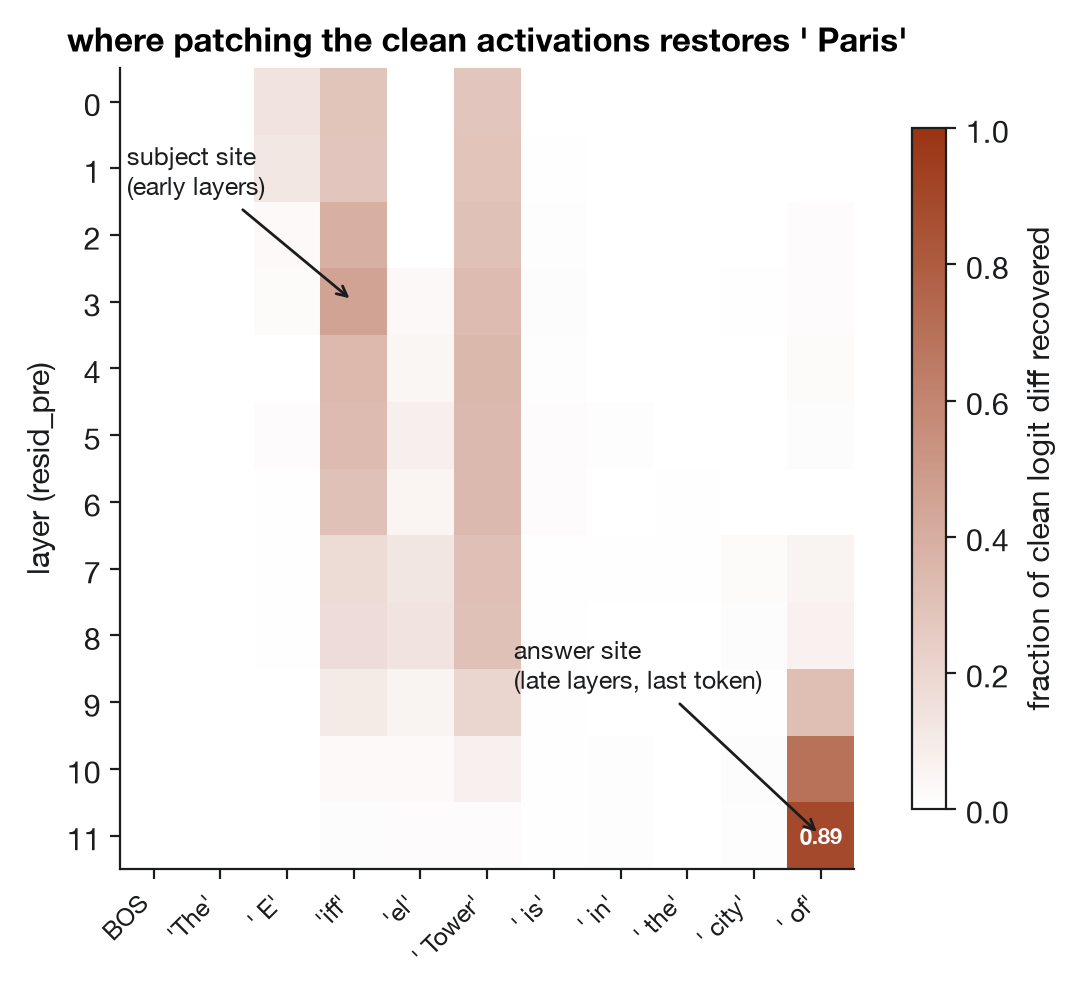

In [9]:
#| label: fig-patching-heatmap
#| fig-cap: "Logit-diff recovery when the clean residual stream is patched at each (layer, position). The answer sits at the subject tokens early, then jumps to the final position near layer 9."
#| fig-alt: "Heatmap of logit-difference recovery by layer and position: recovery sits at the subject tokens in early layers, then jumps to the final position around layer 9."
str_toks = model.to_str_tokens(clean_prompt)
labels = ["BOS" if t == "<|endoftext|>" else repr(t) for t in str_toks]

fig, ax = plt.subplots(figsize=(7.5, 5.2))
im = ax.imshow(patch_result, cmap=rust_cmap, vmin=0, vmax=1)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(n_layers))
ax.set_ylabel("layer (resid_pre)")
ax.set_title("where patching the clean activations restores ' Paris'")
ax.grid(False)

best_layer, best_pos = divmod(patch_result.argmax().item(), patch_result.shape[1])
ax.text(best_pos, best_layer, f"{patch_result[best_layer, best_pos]:.2f}",
        ha="center", va="center", fontsize=8, color="white", fontweight="bold")
early = patch_result[:8]
e_layer, e_pos = divmod(early.argmax().item(), early.shape[1])
ax.annotate("subject site\n(early layers)", xy=(e_pos, e_layer), xytext=(e_pos - 3.4, e_layer - 1.6),
            fontsize=9, color=INK, arrowprops={"arrowstyle": "->", "color": INK})
ax.annotate("answer site\n(late layers, last token)", xy=(best_pos, best_layer),
            xytext=(best_pos - 4.6, best_layer - 2.2),
            fontsize=9, color=INK, arrowprops={"arrowstyle": "->", "color": INK})
fig.colorbar(im, ax=ax, shrink=0.85, label="fraction of clean logit diff recovered")
plt.show()

Two sites light up, and the gap between them **is** the finding: in layers 0-8 the fact travels with the *subject tokens* (' Tower' and the 'iff' inside Eiffel, recovery ≈ 0.3), then from ~layer 9 onward it only matters at the *final position* (recovery 0.89 at L11). Somewhere in between, attention heads ferry the retrieved fact from the subject to the prediction site, the same early-site/late-site geometry that ROME-style model-editing work exploits, reproduced here in ~3 seconds of CPU time.

Note what patching did NOT tell us: *which heads* do the ferrying, or *what representation* moves. Position-level resid patching is a map, not a mechanism. The exercise at the end pushes one level deeper.

## 4. Sparse autoencoders: unmixing the residual stream

Chapter 3 measured GPT-2's embedding anisotropy; here is its consequence: the model packs far more concepts than it has dimensions, so individual neurons mean five things at once (**superposition**). A sparse autoencoder (SAE) is a learned change of basis: encode the 768-dim residual stream into 24,576 features under a sparsity penalty, decode back with minimal loss. If it works, each *feature* (unlike each neuron) tends to mean one thing.

We load a public SAE trained by Joseph Bloom on `blocks.8.hook_resid_pre` of GPT-2 small (the `gpt2-small-res-jb` release, trained on OpenWebText). Every feature in this release has a public dashboard: `https://www.neuronpedia.org/gpt2-small/8-res-jb/<feature_id>`. Paste any feature id you find below.

*Smoke mode skips this section (it downloads ~330 MB of SAE weights).*

In [10]:
SAE_HOOK = "blocks.8.hook_resid_pre"

if SMOKE:
    sae = None
    print("smoke mode: skipping SAE download, rerun without BOOK_SMOKE=1 for sections 4-5")
else:
    from sae_lens import SAE

    # Note: this release warns about model_from_pretrained_kwargs, for res-jb the
    # kwarg is center_writing_weights=True, which is already transformer-lens's
    # default loading behavior, so our activations match its training distribution.
    sae = SAE.from_pretrained("gpt2-small-res-jb", SAE_HOOK, device=DEVICE)
    d_sae = int(sae.cfg.d_sae)
    print(f"SAE: {d_sae} features over d_model={model.cfg.d_model} "
          f"({d_sae // model.cfg.d_model}x overcomplete)")

    sentences = [
        "The Golden Gate Bridge towers over the San Francisco Bay.",
        "She poured the coffee and watched the rain against the window.",
        "The court ruled that the contract violated federal law.",
    ]
    for sent in sentences:
        tk = model.to_tokens(sent)
        _, cache8 = model.run_with_cache(tk, names_filter=SAE_HOOK)
        feats = sae.encode(cache8[SAE_HOOK])[0, 1:]  # drop the BOS position
        l0 = (feats > 0).float().sum(-1).mean().item()
        str_tk = model.to_str_tokens(sent)[1:]
        top_vals, top_ids = feats.max(0).values.topk(3)
        peaks = [str_tk[feats[:, fid].argmax().item()] for fid in top_ids]
        print(f"\nL0={l0:5.1f}  {sent}")
        for v, fid, pk in zip(top_vals, top_ids, peaks):
            print(f"   feature {fid.item():5d}  act {v:6.1f}  peaks on {pk!r}")

SAE: 24576 features over d_model=768 (32x overcomplete)

L0= 56.2  The Golden Gate Bridge towers over the San Francisco Bay.
   feature 20677  act   75.1  peaks on ' San'
   feature 10261  act   73.7  peaks on ' Golden'
   feature  9752  act   58.5  peaks on ' Francisco'

L0= 59.9  She poured the coffee and watched the rain against the window.
   feature 21791  act   59.1  peaks on ' rain'
   feature 11521  act   50.8  peaks on ' watched'
   feature  9781  act   48.5  peaks on ' coffee'

L0= 44.7  The court ruled that the contract violated federal law.
   feature 22438  act   53.2  peaks on ' contract'
   feature  7554  act   48.9  peaks on ' federal'
   feature  3084  act   41.5  peaks on ' court'


Out of 24,576 features, only ~40-60 are active per token (**L0** above): that is the sparsity that makes features readable. The top features already look thematic: one peaks on ' San', one on ' rain', one on ' contract'.

A single sentence proves nothing, though. A feature earns an interpretation from its behavior **across a corpus**. Next we run 200 tweets through the SAE and build a miniature version of a Neuronpedia dashboard: top features by activation, and for each, the exact tokens that fire it.

::: {.callout-warning}
**Content note.** The tweets below are raw social media text (`tweet_eval`), unfiltered; a few exemplar snippets contain profanity. We keep them as-is: sanitizing the corpus would misrepresent what the feature actually responds to.
:::

In [11]:
if SMOKE:
    print("smoke mode: skipped")
else:
    try:
        from datasets import load_dataset
        _ds = load_dataset("tweet_eval", "sentiment", split="train")
        texts = [_ds[i]["text"] for i in range(400) if len(_ds[i]["text"]) > 40][:200]
        corpus_name = "tweet_eval/sentiment train[:200 filtered]"
    except Exception as err:  # offline fallback, tiny inline sample
        print(f"datasets unavailable ({err}); using inline fallback corpus")
        texts = [
            "Just landed in San Diego and the tacos are already incredible.",
            "Can't believe the referee missed that call in the final minute.",
            "Reading the new sci-fi novel everyone keeps recommending.",
            "The traffic on the bridge this morning was absolutely brutal.",
            "Our flight to San Jose got delayed by three hours again.",
            "This coffee shop plays the best jazz on Sunday mornings.",
            "The senator's speech did not address the housing crisis at all.",
            "My cat knocked the plant off the shelf and blamed me.",
            "Training for the marathon is going slower than I hoped.",
            "The concert last night was the best show I've seen in years.",
            "Grandma's recipe still beats every restaurant version I've tried.",
            "The stock dropped eight percent after the earnings call.",
            "Hiking in the rain sounds bad but it was actually magical.",
            "The new update broke my favorite feature of the app.",
            "Waves were perfect at the beach this morning, surf was crowded.",
            "He finally fixed the bike after watching one video tutorial.",
            "The museum's new exhibit on ancient maps is worth the trip.",
            "Study group at the library ran three hours past schedule.",
            "The bakery on Fifth Street sold out of croissants by nine.",
            "Lightning storms over the valley kept us up half the night.",
        ]
        corpus_name = "inline fallback (20 sentences)"

    pad_id = model.tokenizer.pad_token_id
    if pad_id is None:
        pad_id = model.tokenizer.eos_token_id

    feat_max = torch.zeros(d_sae)
    batches = []  # (tokens, masked feature acts) for exemplar lookup
    n_tokens = 0
    for i in range(0, len(texts), 16):
        tk = model.to_tokens(texts[i : i + 16])
        _, c8 = model.run_with_cache(tk, names_filter=SAE_HOOK)
        f = sae.encode(c8[SAE_HOOK])
        mask = tk != pad_id
        mask[:, 0] = False  # ignore BOS, its activations are a known artifact
        f = (f * mask.unsqueeze(-1)).cpu()
        feat_max = torch.maximum(feat_max, f.amax(dim=(0, 1)))
        batches.append((tk.cpu(), f))
        n_tokens += int(mask.sum())
    print(f"corpus: {corpus_name} | {len(texts)} texts, {n_tokens} tokens scored")

    def exemplars(fid, n=4):
        hits = []
        for tk, f in batches:
            v = f[:, :, fid]
            for b in range(tk.shape[0]):
                p = v[b].argmax().item()
                if v[b, p] > 0:
                    ctx = model.to_string(tk[b, max(1, p - 6) : p + 1].tolist())
                    hits.append((v[b, p].item(), ctx, model.to_string(tk[b, p].item())))
        hits.sort(reverse=True)
        return hits[:n]

    top8 = feat_max.topk(8)
    dashboard = []
    for fid, val in zip(top8.indices.tolist(), top8.values.tolist()):
        ex = exemplars(fid)
        # decoder-vector logit lens: which output tokens does this feature push?
        boosts = [model.to_string(i.item()) for i in (sae.W_dec[fid] @ model.W_U).topk(4).indices]
        dashboard.append((fid, val, ex, boosts))
        print(f"\nfeature {fid}  (max act {val:.1f})  boosts logits of {boosts}")
        for act, ctx, tok in ex:
            print(f"   {act:6.1f}  ...{ctx!r} -> fires on {tok!r}")

corpus: tweet_eval/sentiment train[:200 filtered] | 200 texts, 5487 tokens scored

feature 9303  (max act 76.4)  boosts logits of ['с', '________________________________________________________________', '________', '________________']
     76.4  ..."G 1st goes AJ's " -> fires on ' '
     76.4  ...'\\u2019s nature. ' -> fires on ' '
     75.6  ...' you plan to read it? ' -> fires on ' '
     75.3  ..." he's gonna fuck you up " -> fires on ' '

feature 16845  (max act 74.6)  boosts logits of ['ooting', 'ooter', 'ifting', 'allow']
     74.6  ...'"Sh' -> fires on 'Sh'
     66.2  ...'Sh' -> fires on 'Sh'
      4.3  ...' may be unfortunate bt we sh' -> fires on ' sh'

feature 20677  (max act 74.2)  boosts logits of [' Francisco', ' Diego', 'ctuary', ' Antonio']
     74.2  ...' pass to Eddie Royal to the San' -> fires on ' San'
     46.3  ...', Manny Machado and Miguel San' -> fires on ' San'

feature 9620  (max act 74.2)  boosts logits of ['lington', 'rah', 'geon', 'ques']
     74.2  ...'20

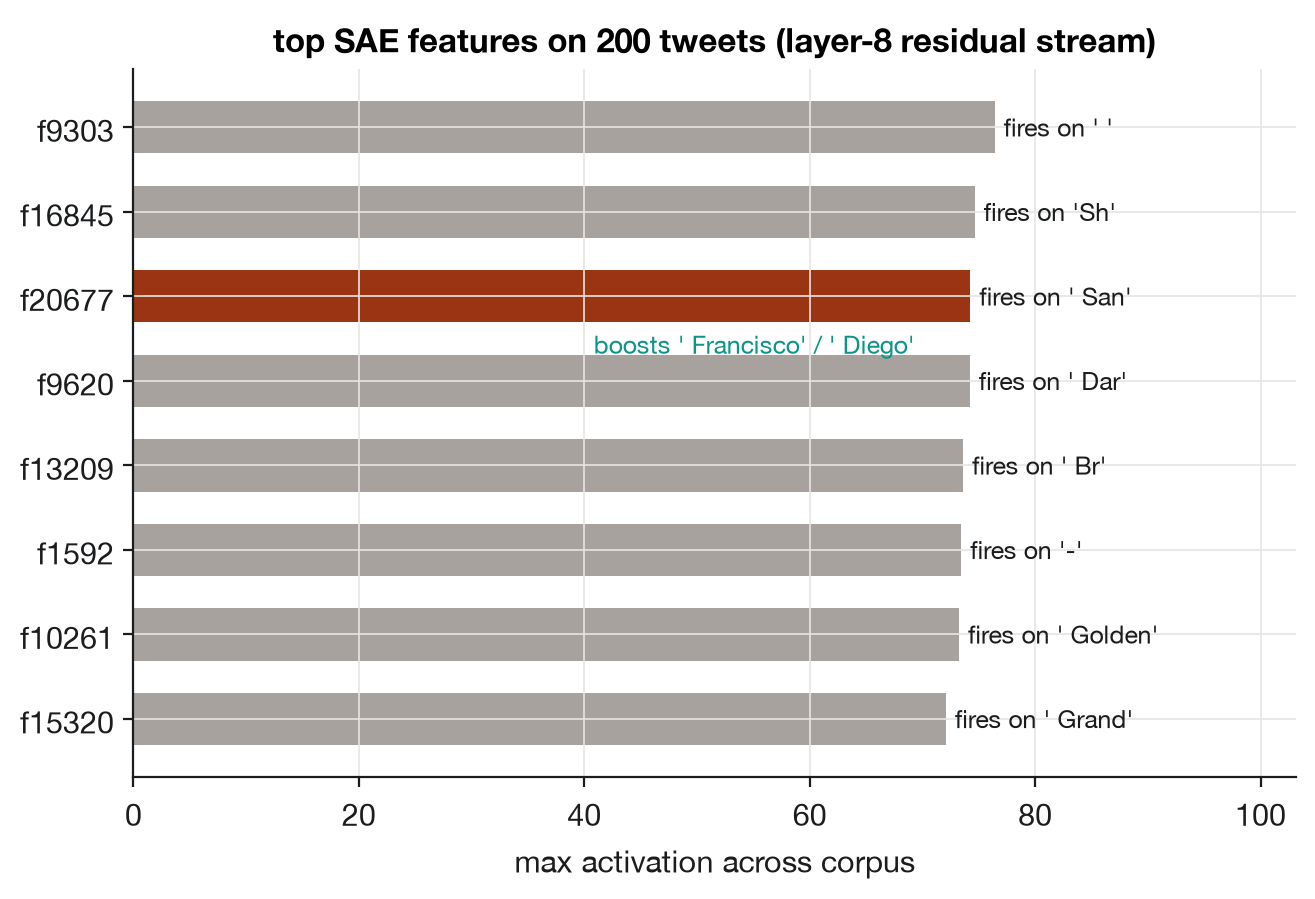

In [12]:
#| label: fig-sae-features
#| fig-cap: "The eight strongest SAE features across 200 tweets, each labeled with the token it fires on hardest. The strongest is whitespace bookkeeping; a 'San ___' city feature hides mid-pack."
#| fig-alt: "Dashboard of the eight strongest sparse autoencoder features across 200 tweets, each labeled with the token it fires on hardest."
if SMOKE:
    print("smoke mode: skipped (no SAE loaded)")
else:
    fig, ax = plt.subplots(figsize=(7.5, 4.6))
    ids = [f"f{fid}" for fid, _, _, _ in dashboard][::-1]
    vals = [val for _, val, _, _ in dashboard][::-1]
    peak_toks = [ex[0][2] if ex else "?" for _, _, ex, _ in dashboard][::-1]
    bar_colors = [RUST if fid == "f20677" else STONE for fid in ids]
    bars = ax.barh(ids, vals, color=bar_colors, height=0.62)
    for bar, tok in zip(bars, peak_toks):
        ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2,
                f"fires on {tok!r}", va="center", fontsize=9, color=INK)
    if "f20677" in ids:
        j = ids.index("f20677")
        boosts = next(b for fid, _, _, b in dashboard if fid == 20677)
        ax.text(vals[j] * 0.55, j - 0.68, "boosts " + " / ".join(repr(t) for t in boosts[:2]),
                fontsize=9, color=TEAL)
    ax.set_xlim(0, max(vals) * 1.35)
    ax.set_xlabel("max activation across corpus")
    ax.set_title("top SAE features on 200 tweets (layer-8 residual stream)")
    plt.show()

An honest dashboard, not a curated one: the **strongest** feature on tweets (f9303) fires on runs of trailing whitespace. Its decoder vector boosts underscore and dash strings. Formatting bookkeeping, not meaning. Several others are token-fragment detectors ('Sh', 'G'). This is what SAE output really looks like; papers show you the pretty tail.

The pretty tail exists though. **Feature 20677** fires on ' San' and its decoder vector boosts ' Francisco', ' Diego', ' Antonio', ' Bernardino': a genuine "San + city-name" feature. Check it against its public dashboard at [neuronpedia.org/gpt2-small/8-res-jb/20677](https://www.neuronpedia.org/gpt2-small/8-res-jb/20677). Since it both *detects* a context and *promotes* specific continuations, it is the perfect handle for the next experiment.

## 5. Steering: adding a feature back in

If feature 20677 really *causes* San-Francisco-flavored predictions, we should be able to inject it: add `alpha * W_dec[20677]` to the layer-8 residual stream at every position and watch the next-token distribution move. This is the same causal logic as patching, but with a one-dimensional, human-labeled intervention instead of a whole cached activation.

Expectations set honestly: GPT-2 small is tiny, one feature is one direction, and we are pushing the stream off-distribution. Watch both the success *and* the failure modes.

In [13]:
if SMOKE:
    print("smoke mode: skipped")
else:
    SAN_FID = 20677
    steer_vec = sae.W_dec[SAN_FID]  # unit-norm decoder direction
    SAN = model.to_single_token(" San")

    def steered_probs(prompt, alpha):
        def add_feature(resid, hook):
            resid[:, 1:, :] += alpha * steer_vec  # skip BOS
            return resid

        hooks = [(SAE_HOOK, add_feature)] if alpha else []
        with model.hooks(fwd_hooks=hooks):
            logits = model(model.to_tokens(prompt))
        return torch.softmax(logits[0, -1], dim=-1)

    for prompt in ["I grew up in the city of", "My favorite food is"]:
        print(f"\n{prompt!r}")
        for alpha in [0, 20, 80]:
            probs = steered_probs(prompt, alpha)
            tk = probs.topk(5)
            tops = ", ".join(f"{model.to_string(i.item())!r} {v:.3f}" for v, i in zip(tk.values, tk.indices))
            print(f"  alpha={alpha:2d}  p(' San')={probs[SAN].item():.4f}  top-5: {tops}")


'I grew up in the city of'


  alpha= 0  p(' San')=0.0220  top-5: ' Chicago' 0.024, ' New' 0.023, ' San' 0.022, ' St' 0.016, ' Los' 0.016
  alpha=20  p(' San')=0.0767  top-5: ' San' 0.077, ' Los' 0.027, ' Santa' 0.020, ' Chicago' 0.017, ' St' 0.015
  alpha=80  p(' San')=0.0050  top-5: ' Diego' 0.298, ' Francisco' 0.262, ' Jose' 0.048, ' Antonio' 0.043, ' Luis' 0.014

'My favorite food is'
  alpha= 0  p(' San')=0.0001  top-5: ' the' 0.082, ' a' 0.031, ' always' 0.020, ' my' 0.019, ' chicken' 0.018
  alpha=20  p(' San')=0.0004  top-5: ' the' 0.071, ' a' 0.034, ' always' 0.029, ' my' 0.026, ' definitely' 0.017
  alpha=80  p(' San')=0.0026  top-5: ' Francisco' 0.097, ' Diego' 0.064, ' Jose' 0.019, ' Jo' 0.014, ' Antonio' 0.014


Three regimes, all instructive:

- **alpha=20** (≈ feature scale /4): on the city prompt, ' San' jumps from p=0.022 (rank 3) to p=0.077 (top-1). Clean, targeted steering.
- **alpha=80** (≈ the feature's max observed activation): the model now predicts ' Diego' and ' Francisco' *directly*. It behaves as if the previous token already **was** "San", and would happily write "the city of Diego". The intervention overwrote context instead of nudging it.
- **Off-topic prompt** ("My favorite food is"): near-total resistance until alpha=80, where it blurts ' Francisco' as a non-sequitur. Steering does not gracefully integrate with context; it competes with it.

One feature, one direction, three lines of hook code. But the dose-response curve is nonlinear and prompt-dependent. Production-grade steering (Chapter 12 returns to this) needs exactly the evaluation discipline of Chapter 8.

## 6. Scaling up: Gemma Scope on Colab

Everything above transfers verbatim to a modern model. DeepMind's **Gemma Scope** releases SAEs for every layer of Gemma-2-2B/9B: same `sae_lens` API, same encode/steer recipes, features browsable on Neuronpedia under `gemma-2-2b`. What changes:

| | this notebook | Gemma Scope |
|---|---|---|
| model | `gpt2` (124M, open) | `gemma-2-2b` (gated: accept license + `HF_TOKEN`) |
| SAE release | `gpt2-small-res-jb` | `gemma-scope-2b-pt-res-canonical` |
| SAE id | `blocks.8.hook_resid_pre` | `layer_20/width_16k/canonical` |
| features | 24,576 | 16,384 per layer (up to 1M in the wide releases) |
| hardware | any CPU | ~12 GB RAM/VRAM (bf16), Colab T4 works |

The cell below is **off by default**: it downloads ~5 GB and needs a Hugging Face token with the Gemma license accepted. Flip `RUN_GEMMA = True` on Colab to run it.

In [14]:
RUN_GEMMA = False  # flip to True on Colab (needs HF token + accepted gemma-2 license)

if RUN_GEMMA and not SMOKE:
    from sae_lens import SAE

    gemma = HookedTransformer.from_pretrained("gemma-2-2b", device=DEVICE, dtype=torch.bfloat16)
    gemma_sae = SAE.from_pretrained(
        "gemma-scope-2b-pt-res-canonical", "layer_20/width_16k/canonical", device=DEVICE
    )
    gemma_hook = gemma_sae.cfg.metadata.hook_name  # blocks.20.hook_resid_post
    tk = gemma.to_tokens("The Golden Gate Bridge towers over the San Francisco Bay.")
    _, gcache = gemma.run_with_cache(tk, names_filter=gemma_hook)
    gfeats = gemma_sae.encode(gcache[gemma_hook])[0, 1:]
    top_vals, top_ids = gfeats.max(0).values.topk(5)
    print(f"L0 = {(gfeats > 0).float().sum(-1).mean().item():.1f}")
    for v, fid in zip(top_vals, top_ids):
        print(f"  feature {fid.item():6d}  act {v:7.1f}  "
              f"https://www.neuronpedia.org/gemma-2-2b/20-gemmascope-res-16k/{fid.item()}")
else:
    print("skipped: set RUN_GEMMA = True on Colab (gated model, ~5 GB download)")

skipped: set RUN_GEMMA = True on Colab (gated model, ~5 GB download)


## 7. Limits, illusions, and open problems

Everything in this chapter can mislead, and it is worth being precise about how. **Patching** is relative to your corruption: swapping Colosseum for Eiffel localizes what *differs between those two prompts*, not "where facts are stored". A different contrast pair can light up different sites, and near-zero recovery does not prove a component is uninvolved (backup heads that compensate for ablations are well documented). **SAE features** are not ground truth: our dashboard's top feature was whitespace bookkeeping, exemplar reading is biased by the corpus you scored (tweets gave us sports fragments, not DNA), and the same SAE trained twice yields overlapping-but-different dictionaries. Features are *a* useful basis, not *the* basis. And **steering** showed its own illusion: at alpha=80 we didn't strengthen a concept, we bulldozed the context. The honest posture: mechanistic tools generate strong, testable hypotheses about causal structure. They do not yet issue certificates. When a claim matters, triangulate: patch + ablate + steer, and check the effect survives prompt variation (Chapter 8's evaluation discipline, one level down the stack).

## Now try it on your own data

Localize a *different* fact. The skeleton below patches "The Great Wall is in the country of" (China) against "The Grand Canyon is in the country of" (America). Swap in your own pair and see whether the subject-site to answer-site geometry from @fig-patching-heatmap is a general law of GPT-2 or a quirk of the Eiffel Tower.

In [15]:
# Exercise: localize your own fact with activation patching.
# 1. TODO: replace the pair below with your own clean/corrupted prompts.
#    Rules: they must differ ONLY in the subject, and tokenize to the SAME length
#    (the assert is your guardrail, reword until it passes).
ex_clean = "The Great Wall is in the country of"
ex_corrupt = "The Grand Canyon is in the country of"
ex_answer, ex_foil = " China", " America"  # TODO: single-token answers only

ex_clean_toks = model.to_tokens(ex_clean)
ex_corrupt_toks = model.to_tokens(ex_corrupt)
assert ex_clean_toks.shape == ex_corrupt_toks.shape, "reword until both prompts tokenize to the same length"
ANS = model.to_single_token(ex_answer)
FOIL = model.to_single_token(ex_foil)

def ex_diff(logits):
    return logits[0, -1, ANS] - logits[0, -1, FOIL]

ex_clean_logits, ex_clean_cache = model.run_with_cache(ex_clean_toks)
EX_CLEAN = ex_diff(ex_clean_logits).item()
EX_CORRUPT = ex_diff(model(ex_corrupt_toks)).item()
print(f"logit diff: clean {EX_CLEAN:+.3f} | corrupted {EX_CORRUPT:+.3f}")

def ex_metric(logits):
    return (ex_diff(logits) - EX_CORRUPT) / (EX_CLEAN - EX_CORRUPT)

ex_result = patching.get_act_patch_resid_pre(model, ex_corrupt_toks, ex_clean_cache, ex_metric).cpu()
ex_layer, ex_pos = divmod(ex_result.argmax().item(), ex_result.shape[1])
ex_strs = model.to_str_tokens(ex_clean)
print(f"max recovery {ex_result.max():.2f} at layer {ex_layer}, position {ex_pos} ({ex_strs[ex_pos]!r})")

# TODO 2: plot ex_result as a heatmap (copy the fig-patching-heatmap cell).
# TODO 3: go one level deeper, patch attention-head outputs instead of the
#         residual stream with patching.get_act_patch_attn_head_out_all_pos
#         and find WHICH heads ferry the fact to the final position.
# TODO 4 (full mode): run your clean prompt through the SAE, is there a
#         feature for your subject? Look it up on Neuronpedia.

logit diff: clean +0.636 | corrupted -2.137


max recovery 0.94 at layer 0, position 3 (' Wall')
